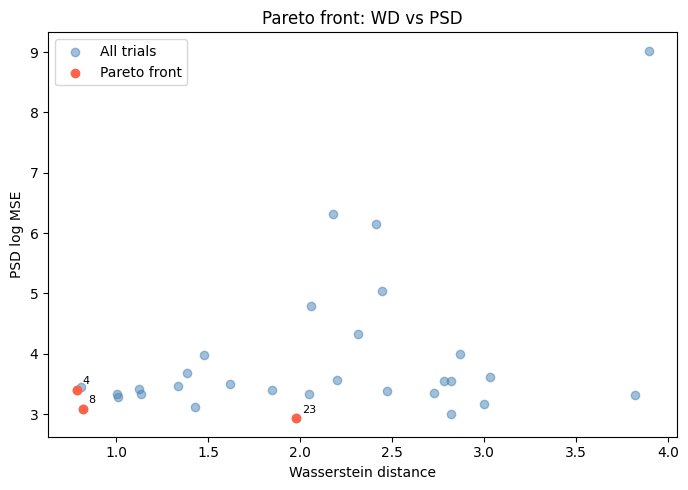

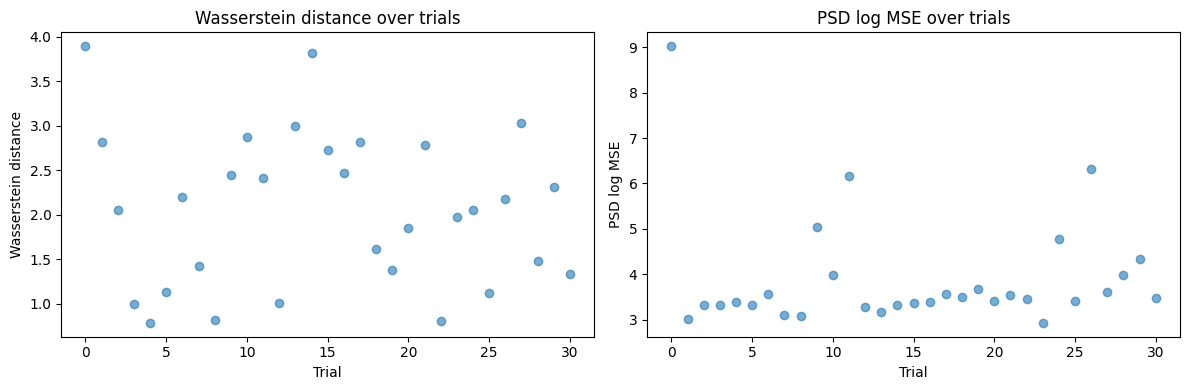

In [1]:
import optuna
import pandas as pd
import matplotlib.pyplot as plt

study = optuna.load_study(
    study_name='distribution_v3',
    storage='sqlite:///optuna_distribution_v3.db'
)

df = study.trials_dataframe()
df_done = df[df['state'] == 'COMPLETE'].copy()
df_done.columns = [c.replace('values_', 'obj_') if c.startswith('values_') else c for c in df_done.columns]

# Rename for clarity
df_done = df_done.rename(columns={'obj_0': 'WD', 'obj_1': 'PSD'})

# Pareto front
pareto = study.best_trials

wd_pareto   = [t.values[0] for t in pareto]
psd_pareto  = [t.values[1] for t in pareto]
wd_all      = df_done['WD'].values
psd_all     = df_done['PSD'].values

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(wd_all, psd_all, alpha=0.5, color='steelblue', label='All trials')
ax.scatter(wd_pareto, psd_pareto, color='tomato', zorder=5, label='Pareto front')


# Annotate Pareto points with trial number
for t in sorted(pareto, key=lambda t: t.values[0]):
    ax.annotate(str(t.number), (t.values[0], t.values[1]),
                textcoords='offset points', xytext=(4, 4), fontsize=8)


ax.set_xlabel('Wasserstein distance')
ax.set_ylabel('PSD log MSE')
ax.set_title('Pareto front: WD vs PSD')
ax.legend()
plt.tight_layout()
plt.show()

# Optimization history for each objective
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ['WD', 'PSD'], ['Wasserstein distance', 'PSD log MSE']):
    ax.scatter(df_done['number'], df_done[col], alpha=0.6)
    ax.set_xlabel('Trial')
    ax.set_ylabel(label)
    ax.set_title(f'{label} over trials')
plt.tight_layout()
plt.show()

# Slice plots vs Wasserstein
optuna.visualization.plot_slice(
    study,
    target=lambda t: t.values[0],
    target_name='Wasserstein distance'
).show()

# Slice plots vs PSD log MSE
optuna.visualization.plot_slice(
    study,
    target=lambda t: t.values[1],
    target_name='PSD log MSE'
).show()



In [51]:
from Pretrain import pretrain
from torch import nn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import json

from model_stuff import Predictor
from Rollout import train_rollout
from SingleModel import SingleModel

trial = study.trials[8]
best = trial.params
trial = study.trials[8]
print(trial.params)
print(trial.values)       # (WD, PSD)
print(trial.user_attrs)   # best_k, best_rho, wasserstein, psd_log_mse


{'n_pretrain_epochs': 16, 'train_steps': 300, 'train_horizon': 80, 'hidden_size': 128, 'dropout': 0.25186943456924793, 'lr_pretrain': 0.0017922040787590843, 'lr_rollout': 0.00015168011922146642, 'transition_config': '200_12', 'horizon_boost': True}
[0.8196121042454326, 3.0901078059131932]
{'best_eval_seed': 0, 'best_k': 0.1, 'best_rho': 0.6, 'psd_log_mse': 3.0901078059131932, 'wasserstein': 0.8196121042454326}


In [52]:
X_df = pd.read_csv('../data/CombinedDatasetLongUnsmooth.csv')
X_df = X_df.drop(columns=['AMOC']).rename(columns={'AMOC_40N': 'AMOC'})
model_vars   = ['AMOC', 'SFWF', 'PD_200m']
feature_cols = target_cols = model_vars
train_cut_1, train_cut_2 = 12500, 18500
train_idx = list(range(train_cut_1)) + list(range(train_cut_2, len(X_df)))


y_scalers = {}
X_scaled  = X_df[model_vars].copy().astype(float)
for var in model_vars:
    sc = StandardScaler().fit(X_df[var].values[train_idx].reshape(-1, 1))
    X_scaled[var] = sc.transform(X_df[var].values.reshape(-1, 1))
    y_scalers[var] = sc


x_scaler = StandardScaler().fit(X_df[feature_cols].values[train_idx])

In [53]:
model = Predictor(n_features=3, hidden_size=best['hidden_size'], num_layers=1, dropout=best['dropout'], output_size=3)

pretrain(X_scaled, train_cut_1, train_cut_2, model,
         feature_cols, target_cols,
         lag=150, horizon=1,        
         n_epochs=best['n_pretrain_epochs'], batch_size=64,
         lr=best['lr_pretrain'], loss_fn=nn.MSELoss())

transition_prob = 0.7
amoc_std = y_scalers['AMOC'].scale_[0]
transition_config = best['transition_config']          
search_ahead      = int(transition_config.split('_')[0])
threshold_sv      = float(transition_config.split('_')[1])
threshold_scaled  = threshold_sv / amoc_std



train_rollout(X_scaled, train_cut_1, train_cut_2, transition_prob, threshold_scaled,
              search_ahead, model, feature_cols, target_cols,
              train_steps=best['train_steps'], lag=150, train_horizon=best['train_horizon'], 
              loss_fn=nn.MSELoss(), lr=best['lr_rollout'], seed = 42)


single = SingleModel.from_trained(model, x_scaler, y_scalers)

Epoch 10/16  loss: 0.0326


In [65]:
start_idx_on = 6600
steps = 20000

preds  = single.predict(X_df, start_idx_on, feature_cols, target_cols, lag=175, steps=steps, threshold=14, rho=0.6, k=0.1)



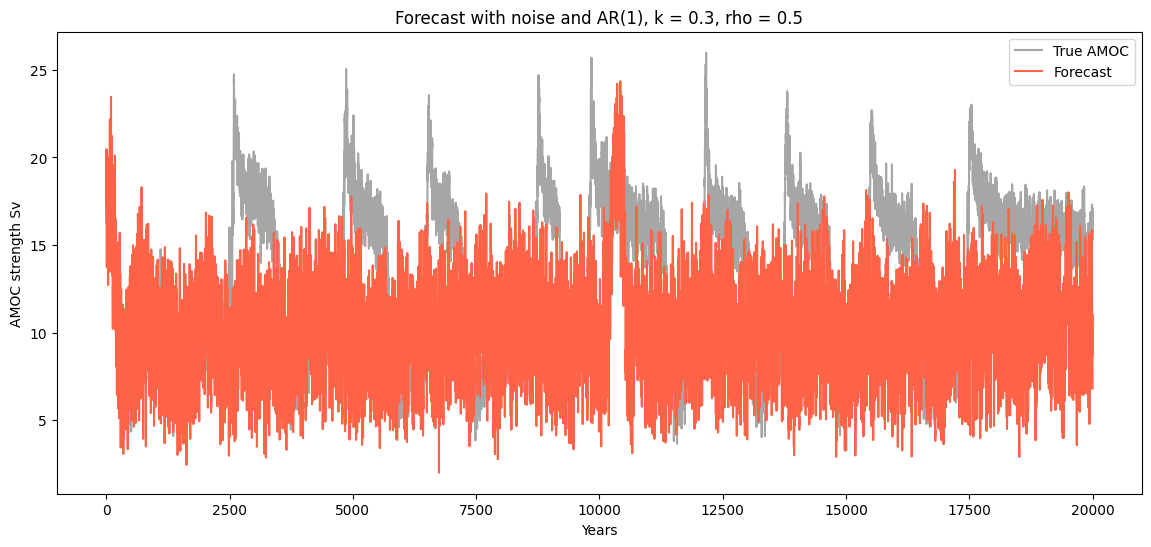

In [66]:
plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, X_df['AMOC'][start_idx_on:start_idx_on+steps], label = 'True AMOC', color = 'grey', alpha = 0.7)
plt.plot(x, preds['AMOC'], label = 'Forecast', color = '#FF6347')
plt.title('Forecast with noise and AR(1), k = 0.3, rho = 0.5')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
plt.legend()

In [69]:
from diagnostics import plot_distribution, plot_power_spectrum

PSD_F_LOW  = 1e-4
PSD_F_HIGH = 1e-2

def _psd(x, fs=1.0):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    N = len(x)
    X = np.fft.rfft(x)
    psd = (np.abs(X) ** 2) / (N * fs)
    psd[1:-1] *= 2.0
    return np.fft.rfftfreq(N, d=1.0 / fs)[1:], psd[1:]

def psd_log_mse(true, pred):
    """Log-scale MSE of PSD restricted to the main AMOC oscillation band."""
    n = min(len(true), len(pred))
    freqs, psd_t = _psd(true[:n])
    _,     psd_p = _psd(pred[:n])
    eps  = 1e-10
    mask = (freqs >= PSD_F_LOW) & (freqs <= PSD_F_HIGH) & (psd_t > eps) & (psd_p > eps)
    return float(np.mean((np.log(psd_p[mask]) - np.log(psd_t[mask])) ** 2))

AMOC_data = pd.read_csv('/Users/isakrockstrom/Desktop/Ocean/AML_proj/data/CombinedDatasetLongUnsmooth.csv')
start_idx = train_cut_1
steps = len(AMOC_data)
preds  = single.predict(X_df, start_idx, feature_cols, target_cols, lag=170, steps=steps, threshold=14, rho=0.6, k=0.1, seed = 0)

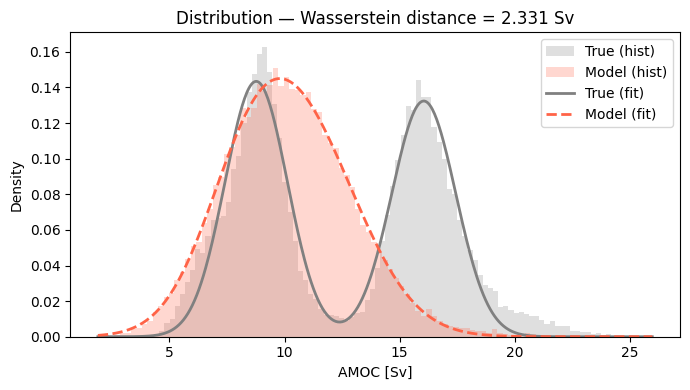

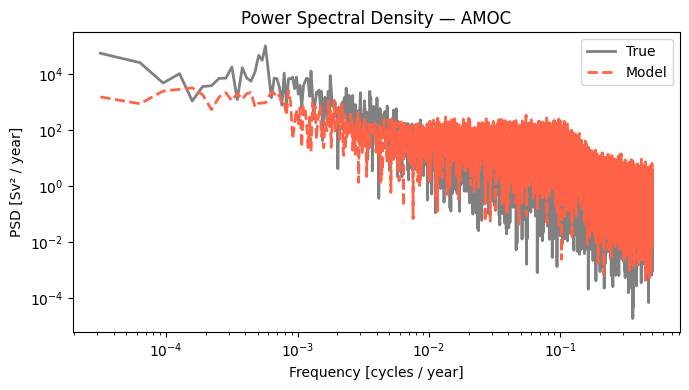

4.8214155113977775


In [71]:
data_color = 'gray'
pred_color = '#FF6347'

psd_loss = psd_log_mse(AMOC_data['AMOC_40N'], preds['AMOC'])

plot_distribution(AMOC_data['AMOC_40N'], preds['AMOC'], var_name='AMOC', true_color = data_color, pred_color=pred_color)
plot_power_spectrum(AMOC_data['AMOC_40N'], preds['AMOC'], var_name='AMOC', true_color = data_color, pred_color=pred_color)
print(psd_loss)

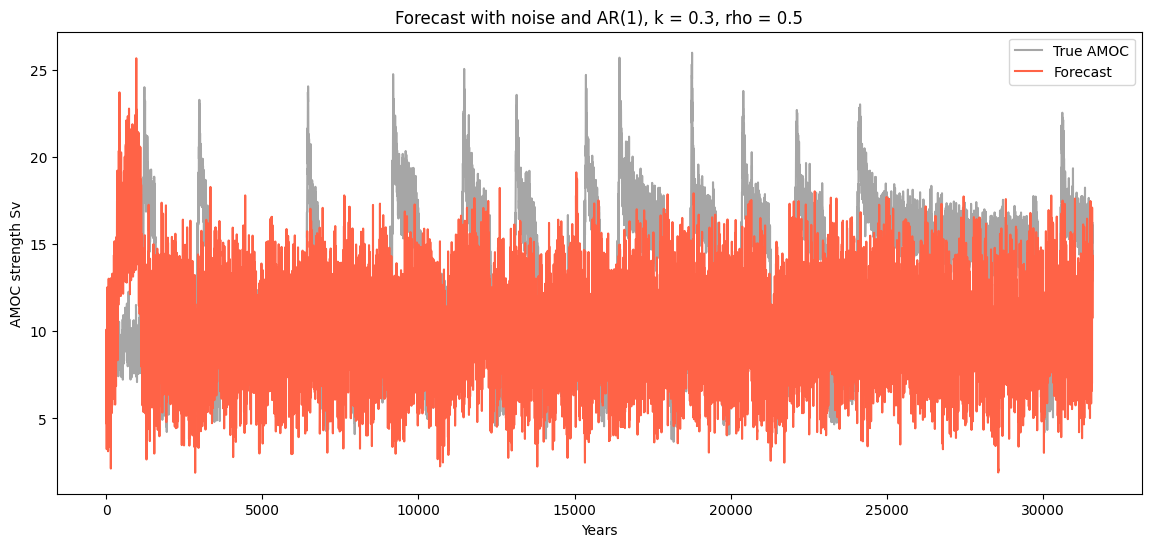

In [72]:
steps = len(X_df)

plt.figure(figsize=(14,6))

x = np.arange(steps)

plt.plot(x, X_df['AMOC'], label = 'True AMOC', color = 'grey', alpha = 0.7)
plt.plot(x, preds['AMOC'], label = 'Forecast', color = '#FF6347')
plt.title('Forecast with noise and AR(1), k = 0.3, rho = 0.5')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
plt.legend()